# 02b. Train/Test Split Analysis

**Project:** KPI-RAG: Explainable Root-Cause Analysis for 5G Networks
**Purpose:** Compare two stratification strategies for the train/test split and select the best one for this dataset.

**The Problem:**
TelecomTS windows overlap by 75% (stride=32, window=128). A recording-level split was attempted
but found impractical — all 1,235 anomalous windows are concentrated in 2 of 33 recording sessions,
resulting in a test set with zero anomalous samples.

**Two Options Compared:**

| Option | stratify= | Guarantees |
|---|---|---|
| A | y_binary | Same 96/4 Normal/Anomaly ratio in train and test |
| B | y_multiclass | Same ratio of every fault type in train and test |

**Output:** Final selected split arrays saved to data folder.

## 1. Imports and Configuration

In [1]:
import numpy as np
import pandas as pd
import os
import json
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from sklearn.model_selection import train_test_split

DATA_DIR     = r'C:\Users\DELL\Desktop\kpi_rag\data'
DATA_PARQUET = r'C:\Users\DELL\Desktop\kpi_rag\data\telecomts_full.parquet'

COLORS = {
    'normal':     '#2E6DB4',
    'anomaly':    '#C0392B',
    'jamming':    '#E67E22',
    'synthetic':  '#85929E',
    'axis':       '#2C3E50',
    'grid':       '#F2F4F6',
    'background': '#FFFFFF',
}

print('Loading saved arrays...')

X            = np.load(os.path.join(DATA_DIR, 'X_features.npy'))
y_binary     = np.load(os.path.join(DATA_DIR, 'y_binary.npy'))
y_multiclass = np.load(os.path.join(DATA_DIR, 'y_multiclass.npy'))

with open(os.path.join(DATA_DIR, 'type_to_int.json')) as f:
    type_to_int = json.load(f)
int_to_type = {v: k for k, v in type_to_int.items()}

df = pd.read_parquet(DATA_PARQUET)

print(f'X shape:          {X.shape}')
print(f'y_binary shape:   {y_binary.shape}')
print(f'y_multiclass shape: {y_multiclass.shape}')
print(f'Fault types: {len(type_to_int) - 1}')

Loading saved arrays...
X shape:          (32000, 582)
y_binary shape:   (32000,)
y_multiclass shape: (32000,)
Fault types: 11


## 2. Option A — Stratify by Binary Label

Preserves the overall 96.1/3.9 Normal/Anomaly ratio in both train and test.
Does not guarantee representation of each fault type.

In [2]:
indices = np.arange(len(df))

train_idx_A, test_idx_A = train_test_split(
    indices,
    test_size=0.2,
    random_state=42,
    stratify=y_binary
)

y_bin_train_A = y_binary[train_idx_A]
y_bin_test_A  = y_binary[test_idx_A]
y_mc_train_A  = y_multiclass[train_idx_A]
y_mc_test_A   = y_multiclass[test_idx_A]

print('Option A — stratify=y_binary')
print(f'  Train: {len(train_idx_A):,} windows')
print(f'  Test:  {len(test_idx_A):,} windows')
print()
print(f'  Train: Normal={np.bincount(y_bin_train_A)[0]:,}  Anomaly={np.bincount(y_bin_train_A)[1]:,}  ({y_bin_train_A.mean()*100:.1f}% anomaly)')
print(f'  Test:  Normal={np.bincount(y_bin_test_A)[0]:,}   Anomaly={np.bincount(y_bin_test_A)[1]:,}   ({y_bin_test_A.mean()*100:.1f}% anomaly)')
print()
print('  Per-class distribution in TEST set:')
print(f'  {"Fault Type":<45} {"Count":>6}  {"% of test anomalies":>20}')
print(f'  {"-"*75}')
test_anomaly_count_A = (y_bin_test_A == 1).sum()
for class_id in range(1, len(type_to_int)):
    count = (y_mc_test_A == class_id).sum()
    pct   = count / test_anomaly_count_A * 100 if test_anomaly_count_A > 0 else 0
    print(f'  {int_to_type[class_id]:<45} {count:>6}  {pct:>19.1f}%')

Option A — stratify=y_binary
  Train: 25,600 windows
  Test:  6,400 windows

  Train: Normal=24,612  Anomaly=988  (3.9% anomaly)
  Test:  Normal=6,153   Anomaly=247   (3.9% anomaly)

  Per-class distribution in TEST set:
  Fault Type                                     Count   % of test anomalies
  ---------------------------------------------------------------------------
  Antenna Failure                                   22                  8.9%
  Buffer Overflow (Gradual Buildup)                 32                 13.0%
  Co-Channel Interference (Mild)                    38                 15.4%
  Co-Channel Interference (Severe)                  25                 10.1%
  Doppler Shift (Severe)                            14                  5.7%
  Faulty Handover Algorithm (Too Frequent)          11                  4.5%
  Faulty RF Filters (Temporal)                      19                  7.7%
  High Network Congestion (Gradual Buildup)         17                  6.9%
  High N

## 3. Option B — Stratify by Multiclass Label

Preserves the ratio of every individual fault type in both train and test.
Guarantees all 11 fault types are represented in the test set.

In [3]:
train_idx_B, test_idx_B = train_test_split(
    indices,
    test_size=0.2,
    random_state=42,
    stratify=y_multiclass
)

y_bin_train_B = y_binary[train_idx_B]
y_bin_test_B  = y_binary[test_idx_B]
y_mc_train_B  = y_multiclass[train_idx_B]
y_mc_test_B   = y_multiclass[test_idx_B]

print('Option B — stratify=y_multiclass')
print(f'  Train: {len(train_idx_B):,} windows')
print(f'  Test:  {len(test_idx_B):,} windows')
print()
print(f'  Train: Normal={np.bincount(y_bin_train_B)[0]:,}  Anomaly={np.bincount(y_bin_train_B)[1]:,}  ({y_bin_train_B.mean()*100:.1f}% anomaly)')
print(f'  Test:  Normal={np.bincount(y_bin_test_B)[0]:,}   Anomaly={np.bincount(y_bin_test_B)[1]:,}   ({y_bin_test_B.mean()*100:.1f}% anomaly)')
print()
print('  Per-class distribution in TEST set:')
print(f'  {"Fault Type":<45} {"Count":>6}  {"% of test anomalies":>20}')
print(f'  {"-"*75}')
test_anomaly_count_B = (y_bin_test_B == 1).sum()
for class_id in range(1, len(type_to_int)):
    count = (y_mc_test_B == class_id).sum()
    pct   = count / test_anomaly_count_B * 100 if test_anomaly_count_B > 0 else 0
    print(f'  {int_to_type[class_id]:<45} {count:>6}  {pct:>19.1f}%')

Option B — stratify=y_multiclass
  Train: 25,600 windows
  Test:  6,400 windows

  Train: Normal=24,612  Anomaly=988  (3.9% anomaly)
  Test:  Normal=6,153   Anomaly=247   (3.9% anomaly)

  Per-class distribution in TEST set:
  Fault Type                                     Count   % of test anomalies
  ---------------------------------------------------------------------------
  Antenna Failure                                   21                  8.5%
  Buffer Overflow (Gradual Buildup)                 27                 10.9%
  Co-Channel Interference (Mild)                    29                 11.7%
  Co-Channel Interference (Severe)                  23                  9.3%
  Doppler Shift (Severe)                            17                  6.9%
  Faulty Handover Algorithm (Too Frequent)          13                  5.3%
  Faulty RF Filters (Temporal)                      20                  8.1%
  High Network Congestion (Gradual Buildup)         19                  7.7%
  Hi

## 4. Visual Comparison

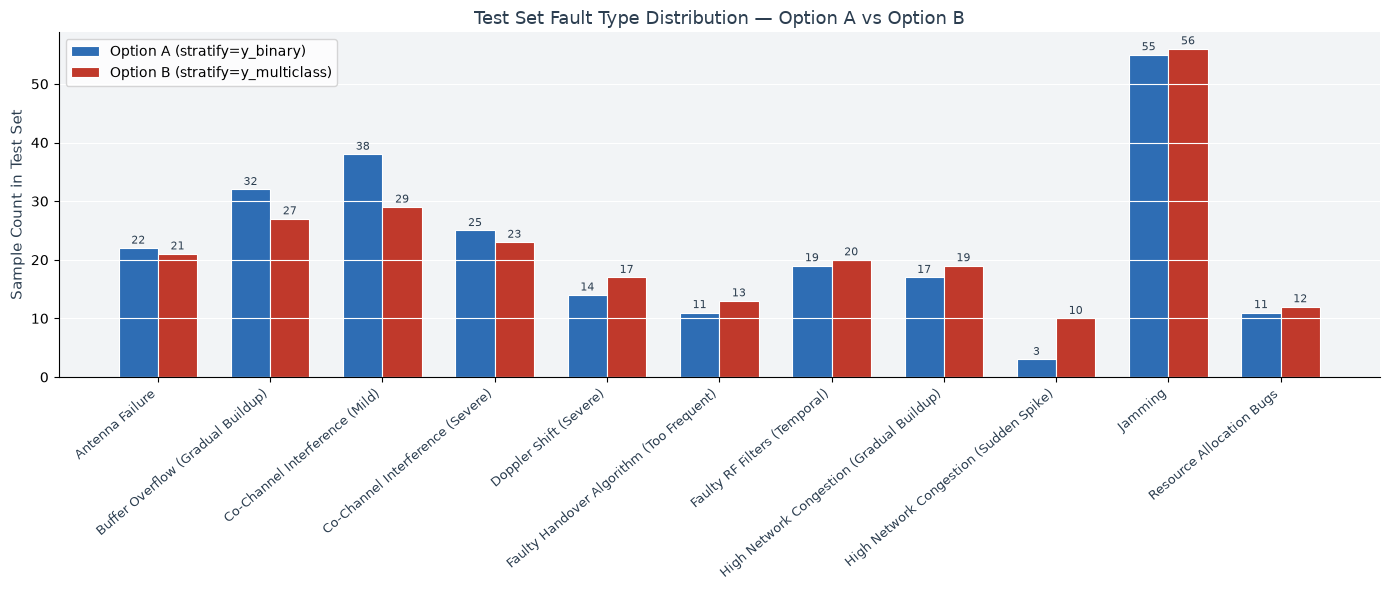

In [4]:
fault_types = [int_to_type[i] for i in range(1, len(type_to_int))]
counts_A    = [(y_mc_test_A == i).sum() for i in range(1, len(type_to_int))]
counts_B    = [(y_mc_test_B == i).sum() for i in range(1, len(type_to_int))]

x      = np.arange(len(fault_types))
width  = 0.35

fig, ax = plt.subplots(figsize=(14, 6))

bars_A = ax.bar(x - width/2, counts_A, width, label='Option A (stratify=y_binary)',
                color=COLORS['normal'], edgecolor='white', linewidth=0.8)
bars_B = ax.bar(x + width/2, counts_B, width, label='Option B (stratify=y_multiclass)',
                color=COLORS['anomaly'], edgecolor='white', linewidth=0.8)

ax.set_xticks(x)
ax.set_xticklabels(fault_types, rotation=40, ha='right', fontsize=9, color=COLORS['axis'])
ax.set_ylabel('Sample Count in Test Set', fontsize=11, color=COLORS['axis'])
ax.set_title('Test Set Fault Type Distribution — Option A vs Option B', fontsize=13, color=COLORS['axis'])
ax.set_facecolor(COLORS['grid'])
ax.grid(axis='y', color='white', linewidth=0.8)
ax.spines[['top', 'right']].set_visible(False)
ax.legend(fontsize=10)

for bar in bars_A:
    if bar.get_height() > 0:
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3,
                str(int(bar.get_height())), ha='center', va='bottom',
                fontsize=8, color=COLORS['axis'])

for bar in bars_B:
    if bar.get_height() > 0:
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3,
                str(int(bar.get_height())), ha='center', va='bottom',
                fontsize=8, color=COLORS['axis'])

plt.tight_layout()
plt.savefig(os.path.join(DATA_DIR, 'split_comparison.png'), dpi=150)
plt.show()

## 5. Summary Table

In [5]:
print('Split Comparison Summary:')
print(f'{"":50} {"Option A":>12} {"Option B":>12}')
print('-' * 76)

print(f'{"stratify=":<50} {"y_binary":>12} {"y_multiclass":>12}')
print(f'{"Train size":<50} {len(train_idx_A):>12,} {len(train_idx_B):>12,}')
print(f'{"Test size":<50} {len(test_idx_A):>12,} {len(test_idx_B):>12,}')
print(f'{"Test anomaly count":<50} {(y_bin_test_A==1).sum():>12,} {(y_bin_test_B==1).sum():>12,}')
print(f'{"Test anomaly ratio":<50} {y_bin_test_A.mean()*100:>11.1f}% {y_bin_test_B.mean()*100:>11.1f}%')
print()

print('Fault types with ZERO test samples:')
zero_A = [int_to_type[i] for i in range(1, len(type_to_int)) if (y_mc_test_A == i).sum() == 0]
zero_B = [int_to_type[i] for i in range(1, len(type_to_int)) if (y_mc_test_B == i).sum() == 0]
print(f'  Option A: {zero_A if zero_A else "None"}')
print(f'  Option B: {zero_B if zero_B else "None"}')
print()
print('Recommendation: Option B guarantees all fault types in test set.')
print('This is required for reliable per-class F1 evaluation in Notebook 03.')

Split Comparison Summary:
                                                       Option A     Option B
----------------------------------------------------------------------------
stratify=                                              y_binary y_multiclass
Train size                                               25,600       25,600
Test size                                                 6,400        6,400
Test anomaly count                                          247          247
Test anomaly ratio                                         3.9%         3.9%

Fault types with ZERO test samples:
  Option A: None
  Option B: None

Recommendation: Option B guarantees all fault types in test set.
This is required for reliable per-class F1 evaluation in Notebook 03.


## 6. Save Final Split

Based on the comparison above — Option B (stratify=y_multiclass) is selected.
It guarantees all 11 fault types are represented in the test set,
which is required for per-class F1 evaluation in Notebook 03.

In [6]:
# Save Option B as the final split
X_train = X[train_idx_B]
X_test  = X[test_idx_B]

y_bin_train = y_binary[train_idx_B]
y_bin_test  = y_binary[test_idx_B]
y_mc_train  = y_multiclass[train_idx_B]
y_mc_test   = y_multiclass[test_idx_B]

np.save(os.path.join(DATA_DIR, 'X_train.npy'),      X_train)
np.save(os.path.join(DATA_DIR, 'X_test.npy'),       X_test)
np.save(os.path.join(DATA_DIR, 'y_bin_train.npy'),  y_bin_train)
np.save(os.path.join(DATA_DIR, 'y_bin_test.npy'),   y_bin_test)
np.save(os.path.join(DATA_DIR, 'y_mc_train.npy'),   y_mc_train)
np.save(os.path.join(DATA_DIR, 'y_mc_test.npy'),    y_mc_test)

np.save(os.path.join(DATA_DIR, 'train_idx.npy'), train_idx_B)
np.save(os.path.join(DATA_DIR, 'test_idx.npy'),  test_idx_B)

print('Final split saved — Option B (stratify=y_multiclass)')
print()
print(f'X_train: {X_train.shape}')
print(f'X_test:  {X_test.shape}')
print()
print(f'Train: Normal={np.bincount(y_bin_train)[0]:,}  Anomaly={np.bincount(y_bin_train)[1]:,}')
print(f'Test:  Normal={np.bincount(y_bin_test)[0]:,}   Anomaly={np.bincount(y_bin_test)[1]:,}')

Final split saved — Option B (stratify=y_multiclass)

X_train: (25600, 582)
X_test:  (6400, 582)

Train: Normal=24,612  Anomaly=988
Test:  Normal=6,153   Anomaly=247


## 7. Validation

In [9]:
zero_in_test = [int_to_type[i] for i in range(1, len(type_to_int))
                if (y_mc_test == i).sum() == 0]

checks = {
    'Train + Test = 32,000':                  X_train.shape[0] + X_test.shape[0] == 32000,
    'All fault types in test set':            len(zero_in_test) == 0,
    'Anomaly ratio preserved in train':       0.037 <= y_bin_train.mean() <= 0.041,
    'Anomaly ratio preserved in test':        0.037 <= y_bin_test.mean() <= 0.041,
    'X_train.npy saved':                      os.path.exists(os.path.join(DATA_DIR, 'X_train.npy')),
    'X_test.npy saved':                       os.path.exists(os.path.join(DATA_DIR, 'X_test.npy')),
}

all_passed = True
for check, passed in checks.items():
    status = 'PASS' if passed else 'FAIL'
    print(f'[{status}] {check}')
    if not passed:
        all_passed = False

print()
if all_passed:
    print('All checks passed.')
else:
    print('One or more checks failed. Investigate before proceeding.')

[PASS] Train + Test = 32,000
[PASS] All fault types in test set
[PASS] Anomaly ratio preserved in train
[PASS] Anomaly ratio preserved in test
[PASS] X_train.npy saved
[PASS] X_test.npy saved

All checks passed.
